In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data_utils

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import numpy as np
import random


# PyTorch 101

This is my first approach to `PyTorch`, tackling a `Regression` task for house price prediction using a Neural Network.

The following exercise includes:

- Exploring the *California Housing* dataset.
- Preprocessing the dataset to make it compatible with PyTorch.
- Building a simple Neural Network for the regression task described above.
- Training the Neural Network while monitoring both training and validation loss.
- Plotting the learning curve from the training history.

In [2]:
# setting seed for reproducibility
SEED = 156
np.random.seed(SEED)
torch.manual_seed(SEED)

## Dataset

California Housing is a famous dataset used for regression.

It contains data on many houses in California and their prices.

Attribute Information:

- ```MedInc```:        median income in block group
- ```HouseAge```:      median house age in block group
- ```AveRooms```:      average number of rooms per household
- ```AveBedrms```:     average number of bedrooms per household
- ```Population```:    block group population
- ```AveOccup```:      average number of household members
- ```Latitude```:      block group latitude
- ```Longitude```:     block group longitude

Target:

- ```Price```: median house value for California districts

For more info: [California Housing Documentation](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html)

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data)
df.columns = housing.feature_names
df['Price'] = housing.target

### Exploratory Data Analysis

Let's explore the dataset to understand the feature distributions, value ranges, and check for any missing values before preprocessing.

In [4]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# check attribute magnitudes
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# check for null values
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

### Data Splitting

We split the data into a **training set** (70%) and a **test set** (30%), using a fixed `SEED` for reproducibility.

In [7]:
X = df[df.columns[:-1]] # dataframe excluding last column
y = pd.DataFrame(df['Price'], columns=['Price']) # last column, our target -> Price

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3, random_state = SEED
)

In [8]:
# check shapes after split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 8)
(6192, 8)
(14448, 1)
(6192, 1)


In [9]:
# remove index column
X_train = X_train.reset_index().drop(columns=['index'])
X_test = X_test.reset_index().drop(columns=['index'])

y_train = y_train.reset_index().drop(columns=['index'])
y_test = y_test.reset_index().drop(columns=['index'])

Let's visualize the distribution of `Price`, our target variable, before any preprocessing.

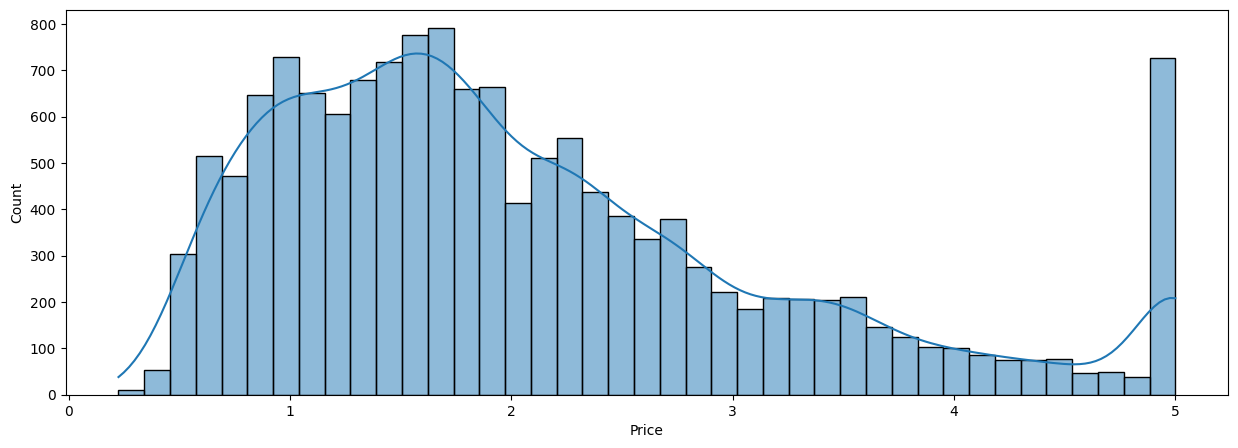

In [10]:
# price visualization
plt.figure(figsize=(15, 5))
sns.histplot(data=y_train, x = 'Price', kde=True)
plt.show()

## Data Preprocessing

### Feature Normalization

The `describe()` output shows that features span very different scales — `Population` reaches 35,682 while `AveBedrms` stays near 1. This imbalance can destabilize gradient updates, causing features with larger magnitudes to dominate.

We apply **min-max normalization** to both the features `X` and the target `y`, scaling all values to the `[0, 1]` range. The min and max are computed **only on the training set** and then reused for the test set to avoid **data leakage**.

In [11]:
# train set normalization
max_df = X_train.max()
min_df = X_train.min()

max_t = y_train.max()
min_t = y_train.min()

X_train_norm = (X_train - min_df)/(max_df - min_df)
y_train_norm = (y_train - min_t)/(max_t - min_t)

In [12]:
# test set normalization
X_test_norm = (X_test - min_df)/(max_df - min_df)
y_test_norm = (y_test - min_t)/(max_t - min_t)

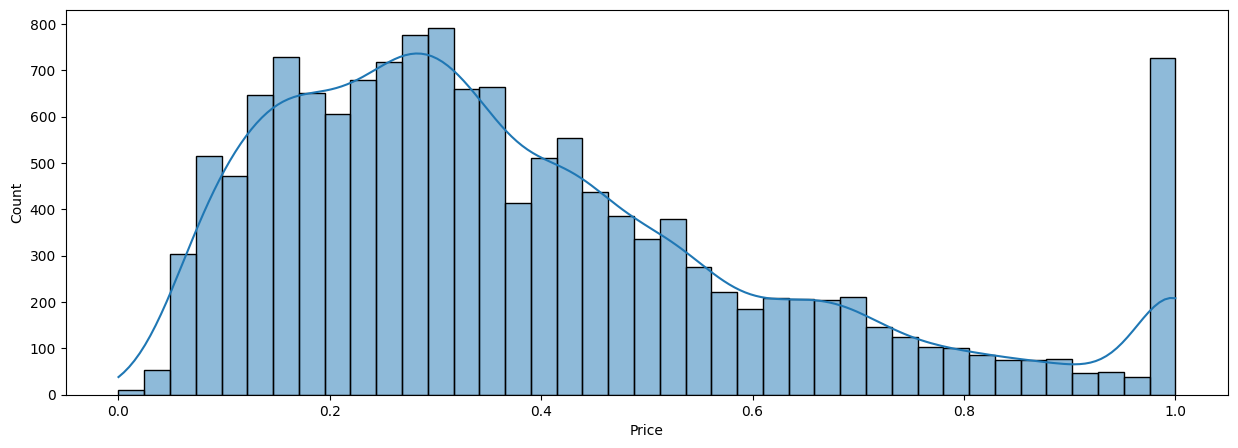

In [13]:
# normalized price visulization 
plt.figure(figsize=(15, 5))
sns.histplot(data=y_train_norm, x = 'Price', kde=True)
plt.show()

The normalized `Price` now falls within `[0, 1]`, making training more stable and loss values directly comparable across epochs.

### Dataset Creation

Converts the preprocessed data for ```PyTorch```.

In [ ]:
train_dataset = data_utils.TensorDataset(torch.tensor(X_train_norm.values, dtype=torch.float32),
                                         torch.tensor(y_train_norm.values, dtype=torch.float32))
train_loader = data_utils.DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = data_utils.TensorDataset(torch.tensor(X_test_norm. values, dtype=torch.float32),
                                         torch.tensor(y_test_norm.values, dtype=torch.float32))
test_loader = data_utils.DataLoader(test_dataset, batch_size=128, shuffle=False)

## Building the Neural Network

Let's create our first NN using ```PyTorch```, it will be composed of two ```Linear Layers``` with a ```ReLU``` between them.

In [15]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=8, out_features=10) # params = (8+1)*10 = 90

        self.layer_2 = nn.Linear(in_features=10, out_features=1) # params = (10+1)*1 = 11

    def forward(self, x):
        x = self.layer_1(x) # input = [batch_size, 8]  -> output = [batch_size, 10]
        x = F.relu(x)       # input = [batch_size, 10] -> output = [batch_size, 10]
        x = self.layer_2(x) # input = [batch_size, 10] -> output = [batch_size, 1]
        return x

In [16]:
net = MLP()
net

MLP(
  (layer_1): Linear(in_features=8, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

Let's try to infer the model before training to see how it behaves.

To do that it is good practice to set our model in ```eval``` mode.

In [17]:
# set mode to evaluation
net.eval()

MLP(
  (layer_1): Linear(in_features=8, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

In [18]:
data_idx = 67

X_t = X_train_norm.iloc[data_idx].to_numpy()
X_t = torch.tensor(X_t, dtype=torch.float)

y_gt = y_train_norm.iloc[data_idx].to_numpy()
y_gt = torch.tensor(y_gt, dtype=torch.float)

with torch.no_grad(): # telling pytorch to not use gradients to improve efficiency
    output = net(X_t)
    print(f"Output: {output}")

print(f"Ground truth: {y_gt}")

Output: tensor([-0.2489])
Ground truth: tensor([0.3550])


## Training Strategy

### Loss Function

We need define a loss function, this step largely depends on the task we are tackling.

In this case we are training a Neural Network for a regression task, therefore we are going to be using the Mean Squared Error ```MSE```.

In [19]:
loss_fn = nn.MSELoss()

### Optimizer

We also need to define an optimizer, the optimizer uses the loss function defined in the step above to adjust and *optimize* the parameters of the Network.

The most commonly used optimizers are ```Adam``` and Stochastic Gradient Descent (```SGD```)

In [20]:
optimizer = torch.optim.SGD(
    params=net.parameters(),
    lr = 0.005   # 5e-3
)

## Training

Set the net to ```train``` mode and start the training process.

In [21]:
epochs = 30

net.train()
for epoch in range(epochs):
    loss_epoch = 0

    for i, data in enumerate(train_loader, 0):

        X = data[0]
        y = data[1]

        # 1. Forward pas
        y_pred = net(X)

        # 2. Loss calculation
        loss = loss_fn(y_pred, y)

        loss_epoch += loss

        # 3. Gradients zeroing (!!important: they tend to cumulate)
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Optimization
        optimizer.step()
    
    print(f"Epoch: {epoch}  |  Train loss: {loss_epoch/len(train_loader)}")

Epoch: 0  |  Train loss: 0.172038272023201
Epoch: 1  |  Train loss: 0.06269296258687973
Epoch: 2  |  Train loss: 0.0607529878616333
Epoch: 3  |  Train loss: 0.060087814927101135
Epoch: 4  |  Train loss: 0.0594450980424881
Epoch: 5  |  Train loss: 0.0588248148560524
Epoch: 6  |  Train loss: 0.05823048949241638
Epoch: 7  |  Train loss: 0.057633429765701294
Epoch: 8  |  Train loss: 0.057056158781051636
Epoch: 9  |  Train loss: 0.05650331452488899
Epoch: 10  |  Train loss: 0.05594346299767494
Epoch: 11  |  Train loss: 0.05538244545459747
Epoch: 12  |  Train loss: 0.05485072731971741
Epoch: 13  |  Train loss: 0.05431165173649788
Epoch: 14  |  Train loss: 0.05376433953642845
Epoch: 15  |  Train loss: 0.05323145166039467
Epoch: 16  |  Train loss: 0.05270136892795563
Epoch: 17  |  Train loss: 0.05216500535607338
Epoch: 18  |  Train loss: 0.051614437252283096
Epoch: 19  |  Train loss: 0.051068659871816635
Epoch: 20  |  Train loss: 0.05054865777492523
Epoch: 21  |  Train loss: 0.0499842241406440

## Evaluation

After the training process we infer the model and check how it behaves.

Again, it is important to set the mode to ```eval```.

In [ ]:
# set evaluation mode
net.eval()

MLP(
  (layer_1): Linear(in_features=8, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

Let's first check the how the prediction for the previous data point changed:

In [24]:
data_idx = 67

X_t = X_train_norm.iloc[data_idx].to_numpy()
X_t = torch.tensor(X_t, dtype=torch.float)

y_gt = y_train_norm.iloc[data_idx].to_numpy()
y_gt = torch.tensor(y_gt, dtype=torch.float)

with torch.no_grad(): # telling pytorch to not use gradients to improve efficiency
    output = net(X_t)
    print(f"Output: {output}")

print(f"Ground truth: {y_gt}")

Output: tensor([0.3410])
Ground truth: tensor([0.3550])


The value is **much** closer to the *ground truth* value, this means our training actually worked!

### Testing Loop

Now let's properly test the Network on the *test data*.

In [26]:
loss_test = 0

for i, data in enumerate(test_loader, 0):

    X = data[0]
    y = data[1]

    with torch.no_grad():

        # 1. Forward pass
        y_pred = net(X)

        # 2. Loss calculation
        loss = loss_fn(y_pred, y)
    
    loss_test += loss

print(f"Testing loss: {loss_test/len(test_loader)}")

Testing loss: 0.04614386707544327


## Monitoring Test Loss

We can also put togther the ```for``` loops in order to monitor Test Loss value during the training process

In [ ]:
epochs = 150

# History tracking
train_loss_values = []
test_loss_values = []
epoch_count = []

net.train()
for epoch in range(epochs):

    net.train()
    train_loss_epoch = 0
    for i, data in enumerate(train_loader, 0):

        X = data[0]
        y = data[1]

        # 1. Forward pas
        y_pred = net(X)

        # 2. Loss calculation
        train_loss = loss_fn(y_pred, y)

        train_loss_epoch += train_loss

        # 3. Gradients zeroing (!!important: they tend to cumulate)
        optimizer.zero_grad()

        # 4. Backpropagation
        train_loss.backward()

        # 5. Optimization
        optimizer.step()
    
    net.eval()
    test_loss_epoch = 0
    for i, data in enumerate(test_loader, 0):

        X = data[0]
        y = data[1]

        with torch.no_grad():

            # 1. Forward pass
            y_pred = net(X)

            # 2. Loss calculation
            loss = loss_fn(y_pred, y)
        
        test_loss_epoch += loss

    # Appending values for history tracking
    epoch_count.append(epoch)
    train_loss_values.append(train_loss_epoch.detach().numpy()/len(train_loader))
    test_loss_values.append(test_loss_epoch.detach().numpy()/len(test_loader))
    print(f"Epoch: {epoch}  |  Train loss: {train_loss_epoch/len(train_loader)}  |  Test loss: {test_loss_epoch/len(test_loader)}")

Epoch: 0  |  Train loss: 0.01976139284670353  |  Test loss: 0.0455721914768219
Epoch: 1  |  Train loss: 0.019511191174387932  |  Test loss: 0.04499519616365433
Epoch: 2  |  Train loss: 0.01926133781671524  |  Test loss: 0.044419001787900925
Epoch: 3  |  Train loss: 0.019012240692973137  |  Test loss: 0.0438445545732975
Epoch: 4  |  Train loss: 0.01876905746757984  |  Test loss: 0.043283745646476746
Epoch: 5  |  Train loss: 0.018517492339015007  |  Test loss: 0.04270360246300697
Epoch: 6  |  Train loss: 0.018270369619131088  |  Test loss: 0.04213371127843857
Epoch: 7  |  Train loss: 0.01802879013121128  |  Test loss: 0.04157659783959389
Epoch: 8  |  Train loss: 0.017784781754016876  |  Test loss: 0.04101388156414032
Epoch: 9  |  Train loss: 0.017536945641040802  |  Test loss: 0.040442343801259995
Epoch: 10  |  Train loss: 0.017298424616456032  |  Test loss: 0.0398922860622406
Epoch: 11  |  Train loss: 0.01705912873148918  |  Test loss: 0.039340440183877945
Epoch: 12  |  Train loss: 0.01

Let's use the history we built to plot a learning curve using the loss values:

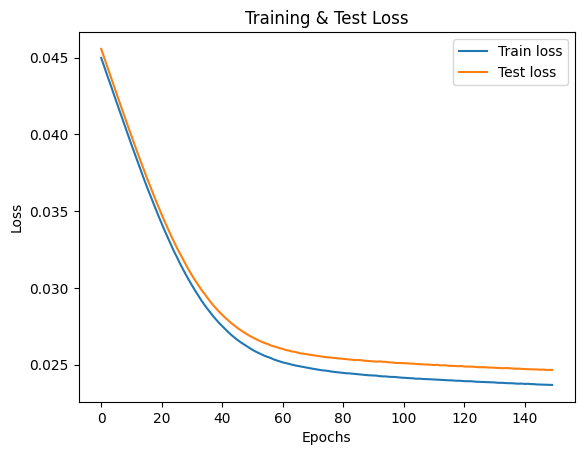

In [30]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training & Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();